# HW Tool

## 1. `shap.plots.beeswarm` нормального человека (4 баллов)

Как вы могли видеть, у встроенного beeswarm plot`а есть несколько недостатков:
- нет информации о том, какие именно значения категориальных признаков в какую сторону толкают предсказания модели
- иногда серые точки (пропущенные значения) прячутся за точками другого цвета -> их не видно (см. rooms_num на графике с семинара)
- иногда раскраска бывает некорректной (потому что она раскрашивает по абсолютным значениям)

Вам предлагается реализовать свою версию shap.plots.beeswarm, которая исправляет эти недостатки.


Итак, требуется написать функцию, которая принимает на вход shap_values и все необходимое и строит по этим данным beeswarm plot
    без вышеперечисленных недостатков, а именно:
- теперь все уникальные значения кат. фич становятся как бы отдельными фичами, по ним видны shap_values (см. пример) ✅
    - чтобы не захламлять ваш график редковстречающимися категориями, принимайте на вход параметр, чтобы контролировать это;
          в примере в качестве такого параметра принимается число от 0 до 1 -- если category_value_rate больше, чем это число,
          то такое category_value имеет право стать самостоятельным ✅
    - такие фичи должны быть покрашены в особый цвет, чтобы отличаться от числовых ✅
- точки, отвечающие за наны, должны быть хорошо видны на фоне остальных и не перекрывать их (быть спереди и не мешать остальным точкам)✅
- раскраска должна адекватно красить ваши точки (используйте покраску по квантилям, палитра coolwarm для числовых) ✅
    - цвета нанов и категорий не должны быть похожи на остальные цвета ✅

**Обязательно:**
- docstring, понятный код
- принимайте на вход кол-во признаков, которые вы отображаете на графике ✅
- принимайте на вход размер фигуры ✅
- нарисуйте вертикальную линию, обозначающую 0 ✅
- сортируйте признаки по среднему модулю shap_values (при сортировке признаков-категорий убедитесь, что вы выкидываете "нули" перед подсчетом среднего модуля) ✅
- используйте stripplot (или аналоги) с jitter`ом, а не swarmplot ✅
- принимайте на вход кол-во точек которое будете отрисовывать (500-3000 = норм) ✅
    - если для какого-то значения кат фичи точек меньше, чем вы задали, рисуйте сколько есть ✅

**!**
Если на вход подана слишком большая выборка, вы можете под капотом сэмплить из нее какое-то адекватное кол-во точек и отрисовывать их.
Однако, раскраску и контроль за отрисовкой категорий лучше базировать на всей выборке, поданной на вход. ✅

**!**
LLM можно!

**!**
Учитывая, что следующий блок домашки в некотором роде "опирается" на этот блок, продумывайте заранее, будете ли вы делать этот блок в статических библиотеках (matplotlib, seaborn) или же в bokeh. Насколько я знаю, и то, и то можно запихнуть в bokeh-приложение при должном желании.


Ниже приведен пример. Не меняйте код, предшествующий примеру. Вы не обязаны повторять пример точь-в-точь, это ориентир. Не удаляйте пример.

Удачи!

In [1]:
import numpy as np, pandas as pd
import lightgbm as lgb

%load_ext autoreload
%autoreload 2


df = pd.read_parquet('sber_data.parquet')
features = ['district_area', 'road_distance_1', 'road_distance_2',
       'year_of_construction', 'bulvar_ring_km', 'bus_station_distance',
       'cafe_count', 'fitness_center_distance', 'floor',
       'district_population', 'total_area', 'green_part',
       'green_zone_distance', 'healthcare_centers_count', 'id',
       'kitchen_area', 'kremlin_distance', 'leisure_count', 'living_area',
       'market_count', 'wall_material', 'floors_num', 'metro_minutes',
       'mkad_distance', 'rooms_num', 'office_count', 'park_distance',
       'product_type', 'public_transport_station_distance', 'sadovoe_km',
       'base_school_distance', 'sport_count', 'state', 'district_name',
       'malls_count', 'railway_station_distance', 'shadow_float_1',
       'shadow_float_2', 'shadow_float_3', 'shadow_float_4',
       'shadow_float_5', 'shadow_cat_big_1', 'shadow_cat_big_2',
       'shadow_cat_big_3', 'shadow_cat_big_4', 'shadow_cat_big_5',
       'shadow_cat_small_1', 'shadow_cat_small_2', 'shadow_cat_small_3',
       'shadow_cat_small_4', 'shadow_cat_small_5']

model = lgb.Booster(model_file='model.lgb')
shap_values = model.predict(df[features], pred_contrib=True)

'''
Учтите, что если вы считаете shap_values через LightGBM,
    shap_values - np.array of shape (N, F + 1), где последний столбец - константа = среднее предсказание для всех объектов
'''
print('features shape:', len(features), 'shap_values shape:', shap_values.shape)
df.head(3)

features shape: 51 shap_values shape: (6264, 52)


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,shadow_cat_big_1,shadow_cat_big_2,shadow_cat_big_3,shadow_cat_big_4,shadow_cat_big_5,shadow_cat_small_1,shadow_cat_small_2,shadow_cat_small_3,shadow_cat_small_4,shadow_cat_small_5
0,7.506452e+06,0.284868,1.478529,NaN,4.395057,6.682089,567,0.810413,14.0,19940,...,181,165,8,143,90,1,2,3,0,0
1,4.787424e+06,2.438125,2.725991,NaN,8.963023,8.571926,292,0.000000,5.0,78810,...,89,34,198,118,55,1,0,0,0,0
2,5.235177e+07,1.454206,1.511580,NaN,12.338744,16.484714,101,0.367100,4.0,78507,...,172,108,20,1,142,0,0,3,3,0


### Пример ниже. Не удаляйте пример!

CPU times: total: 859 ms
Wall time: 866 ms


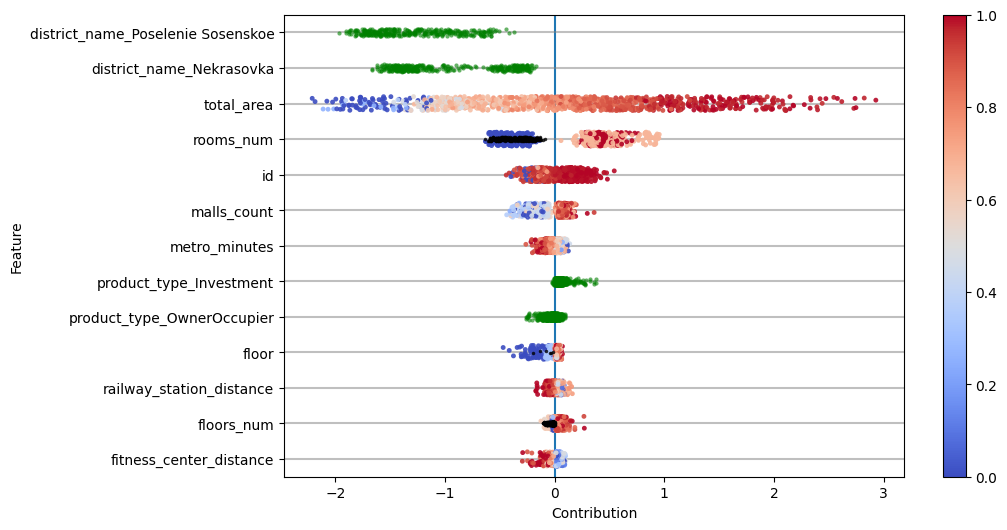

In [ ]:
%%time
from utils import shap_explainer

shap_explainer(model, df, features, cat_feature_threshold=0.001, shap_values=shap_values, top_k=13, figsize=(10, 6), dots=1000)

### решение

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import sklearn
import bokeh
import hdbscan

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import quantile_transform
from bokeh.colors import RGB
from bokeh.palettes import RdBu, Category20
from bokeh.io import output_notebook, curdoc
from bokeh.transform import transform, jitter
from bokeh.plotting import figure, show
from bokeh.layouts import column, row
from matplotlib import cm
from bokeh.models import DataTable, TableColumn, HTMLTemplateFormatter, ColumnDataSource
from bokeh.models import Div, ColumnDataSource, Span, LinearColorMapper, ColorBar, HoverTool, ColorPicker, Dropdown, InlineStyleSheet, Button, TextAreaInput, Select

from bokeh.models.callbacks import CustomJS  # only for copy button

output_notebook()
coolwarm_palette = RdBu # similar to coolwarm

import lightgbm
from lightgbm import LGBMClassifier


Loading BokehJS ...

In [3]:
class ShapBeeswarm:
    """
    interactive SHAP beeswarm plot 

    Parameters
    ----------
    shap_values : np.array or shap.Explainer
        SHAP values from lightboost or shap modules.
    from_lbg: bool
        if shap values came from lightgboost or not
    df : pandas.DataFrame
        raw data (for which shap values were calculated)
    cat_features : list
        if known, one might provide list of categorical features
    max_features : int
        max number of features to be drawn
    cat_thr: float
        frequency of category value to be regarded as individual feature
    num_dots: int
         maximum dots to be drawn for every feature
    figsize: (int, int)
        figsize
    cat_color: str or rgb-color
        color for the category values to be drawn (best: out of blues and reds)
    nan_color: str or rgb-color
        color for the category values to be drawn (best: out of blues and reds)
    """
    def __init__(self, shap_values, from_lbg = True, df = None, cat_features = None, max_features = 10, cat_thr = 0.05, num_dots = 1000, figsize = (10,6), cat_color = 'green', nan_color = '#383232'):
        
        if from_lbg:
            self.data = df
            self.features = self.data.columns
            self.shap_values = pd.DataFrame(data = shap_values[:, :-1], columns = self.features)
            
        else:
            self.shap_values = shap_values.values
            self.features = shap_values.feature_names
            self.data = shap_values.data
            
        self.max_features = max_features
        self.cat_thr = cat_thr
        self.figsize = figsize 
        if num_dots == -1:
            num_dots = float('inf')
        self.num_dots = num_dots
        self.cat_color = cat_color
        self.nan_color = nan_color
        if cat_features:
            self.cat_features = cat_features
        else:
            self.cat_features = self.data.select_dtypes(include=['object', 'str', 'category']).columns
        self.numeric_features = self.data.select_dtypes(include=['int', 'float']).columns
        self.colors = pd.DataFrame(quantile_transform(self.data[self.numeric_features], axis=0, n_quantiles=10), columns = self.numeric_features)
    

        # prepare data for plotting
        self.bokeh_format_df = self._process_data()
        self.feature_order = self.bokeh_format_df.groupby('feature').shap.apply(lambda x: np.mean(np.abs(x[x!=0]))).sort_values(ascending=False).head(self.max_features).index.tolist()
        self.bokeh_format_df = self.bokeh_format_df[self.bokeh_format_df.feature.isin(self.feature_order)]
        self.fig = self._create_figure()

    def _sample_points(self, values, shaps, colors = None):
        if len(values) > self.num_dots:
            idx = np.random.choice(len(values), self.num_dots, replace=False)
            values, shaps = values.iloc[idx], shaps.iloc[idx]
            if colors is not None:
                colors = colors.iloc[idx]

        if colors is not None:
            return values.reset_index(drop=True), shaps.reset_index(drop=True), colors.reset_index(drop=True)
        
        return values.reset_index(drop=True), shaps.reset_index(drop=True)

        
    def _process_feature(self, feature):

        rows = []
        values = self.data[feature].reset_index(drop=True)
        shap_col = self.shap_values[feature].reset_index(drop=True)

        # if we have a category column, we should...
        if feature in self.cat_features:

            # 1) check if cat value freq is greater that self.cat_thr
            for cat, freq in values.value_counts(normalize=True).items():
                if freq > self.cat_thr:
                    mask = (values == cat)  # 2) get mask where feature has this value
                    vals, shaps = self._sample_points(values[mask], shap_col[mask])  # 3) sample

                    # 4) construct it in a shape we will need for bokeh
                    for shap_val, val in zip(shaps, vals):
                        rows.append({
                            "feature": f"{feature}_{cat}",
                            "shap": shap_val,
                            "color": self.cat_color,
                            "value": val
                        })

        # otherwise - numeric 
        elif feature in self.numeric_features:

            nan_idx = np.isnan(values)

            # here we work with non-nan data
            colors = self.colors[feature]
            vals, shaps, cols = self._sample_points(values[~nan_idx], shap_col[~nan_idx], colors[~nan_idx])
            
            # 2) construct it in a shape we will need for bokeh
            for shap_val, val, col in zip(shaps, vals, cols):

                if not np.isnan(shap_val):
                    rows.append({
                        "feature": feature,
                        "shap": shap_val,
                        "color": col,
                        "value": val
                    })
            

            # here we work with nan data
            vals, shaps = self._sample_points(values[nan_idx], shap_col[nan_idx])

            # 2) construct it in a shape we will need for bokeh
            for shap_val, val in zip(shaps, vals):
                if not np.isnan(shap_val):
                    rows.append({
                        "feature": feature,
                        "shap": shap_val,
                        "color": self.nan_color,
                        "value": None
                    })

        return rows

    def _process_data(self):
        all_rows = []
        for feature in self.features:
            all_rows.extend(self._process_feature(feature))
        return pd.DataFrame(all_rows)

    def _create_figure(self):
        fig = figure(
            y_range=list(reversed(self.feature_order)),
            width=int(self.figsize[0]*100),
            height=int(self.figsize[1]*100),
            tools="pan,wheel_zoom,box_zoom,reset,save",
            title = 'Shap Beeswarm',
            x_axis_label='Contribution',  
            y_axis_label='Feature', 
        )

        fig.title.align = "center"
        fig.xaxis.axis_label_text_font_size = "12pt"
        fig.yaxis.axis_label_text_font_size = "12pt"
        fig.title.text_font_size = "15pt"
        fig.title.text_font_style = "bold"
        fig.xaxis.axis_label_text_font_style = "normal"
        fig.yaxis.axis_label_text_font_style = "normal"
        fig.xaxis.major_label_text_font_size = "10pt"
        fig.yaxis.major_label_text_font_size = "10pt"

        fig.xgrid.visible = False
        fig.ygrid.grid_line_color = 'gray'

        vline = Span(location=0, dimension='height', line_color='blue', line_width=1.5, level='underlay')
        fig.add_layout(vline)

        m_coolwarm_rgb = (255 * cm.coolwarm(range(256))).astype('int')
        coolwarm_palette = [RGB(*tuple(rgb)).to_hex() for rgb in m_coolwarm_rgb]

        # make color mapper
        self.color_mapper = LinearColorMapper(palette=coolwarm_palette, low=0, high=1)
        # make color bar
        color_bar = ColorBar(color_mapper = self.color_mapper, location = (5,6))

        num_data = self.bokeh_format_df[self.bokeh_format_df.feature.isin(self.numeric_features)][self.bokeh_format_df.color != self.nan_color]
        cat_data = self.bokeh_format_df[self.bokeh_format_df.color == self.cat_color]
        nan_data = self.bokeh_format_df[self.bokeh_format_df.color == self.nan_color]

        source = ColumnDataSource(num_data)
        fig.circle(
            x="shap",
            y=jitter("feature", width=0.5, range=fig.y_range),
            source=source,
            size=6,
            color=transform("color", self.color_mapper),
            alpha=0.6
        )
        
        source = ColumnDataSource(cat_data)
        fig.circle(
            x="shap",
            y=jitter("feature", width=0.5, range=fig.y_range),
            source=source,
            size=6,
            color="color",
            alpha=0.6
        )


        source = ColumnDataSource(nan_data)
        fig.circle(
            x="shap",
            y=jitter("feature",range=fig.y_range,  width=0.1),
            source=source,
            size=6,
            color="color",
            alpha=0.6
        )

        fig.add_layout(color_bar, 'right')

        hover = HoverTool(tooltips=[("value", "@value"), ("shap", "@shap")])
        fig.add_tools(hover)

        return fig

    def layout(self):
        return self.fig

In [4]:
def app(doc):
    viz = ShapBeeswarm(shap_values=shap_values, df=df, max_features = 13, cat_thr = 0.05, num_dots = 1000, figsize = (10,6))
    doc.add_root(viz.layout())

show(app)

### скрин решения

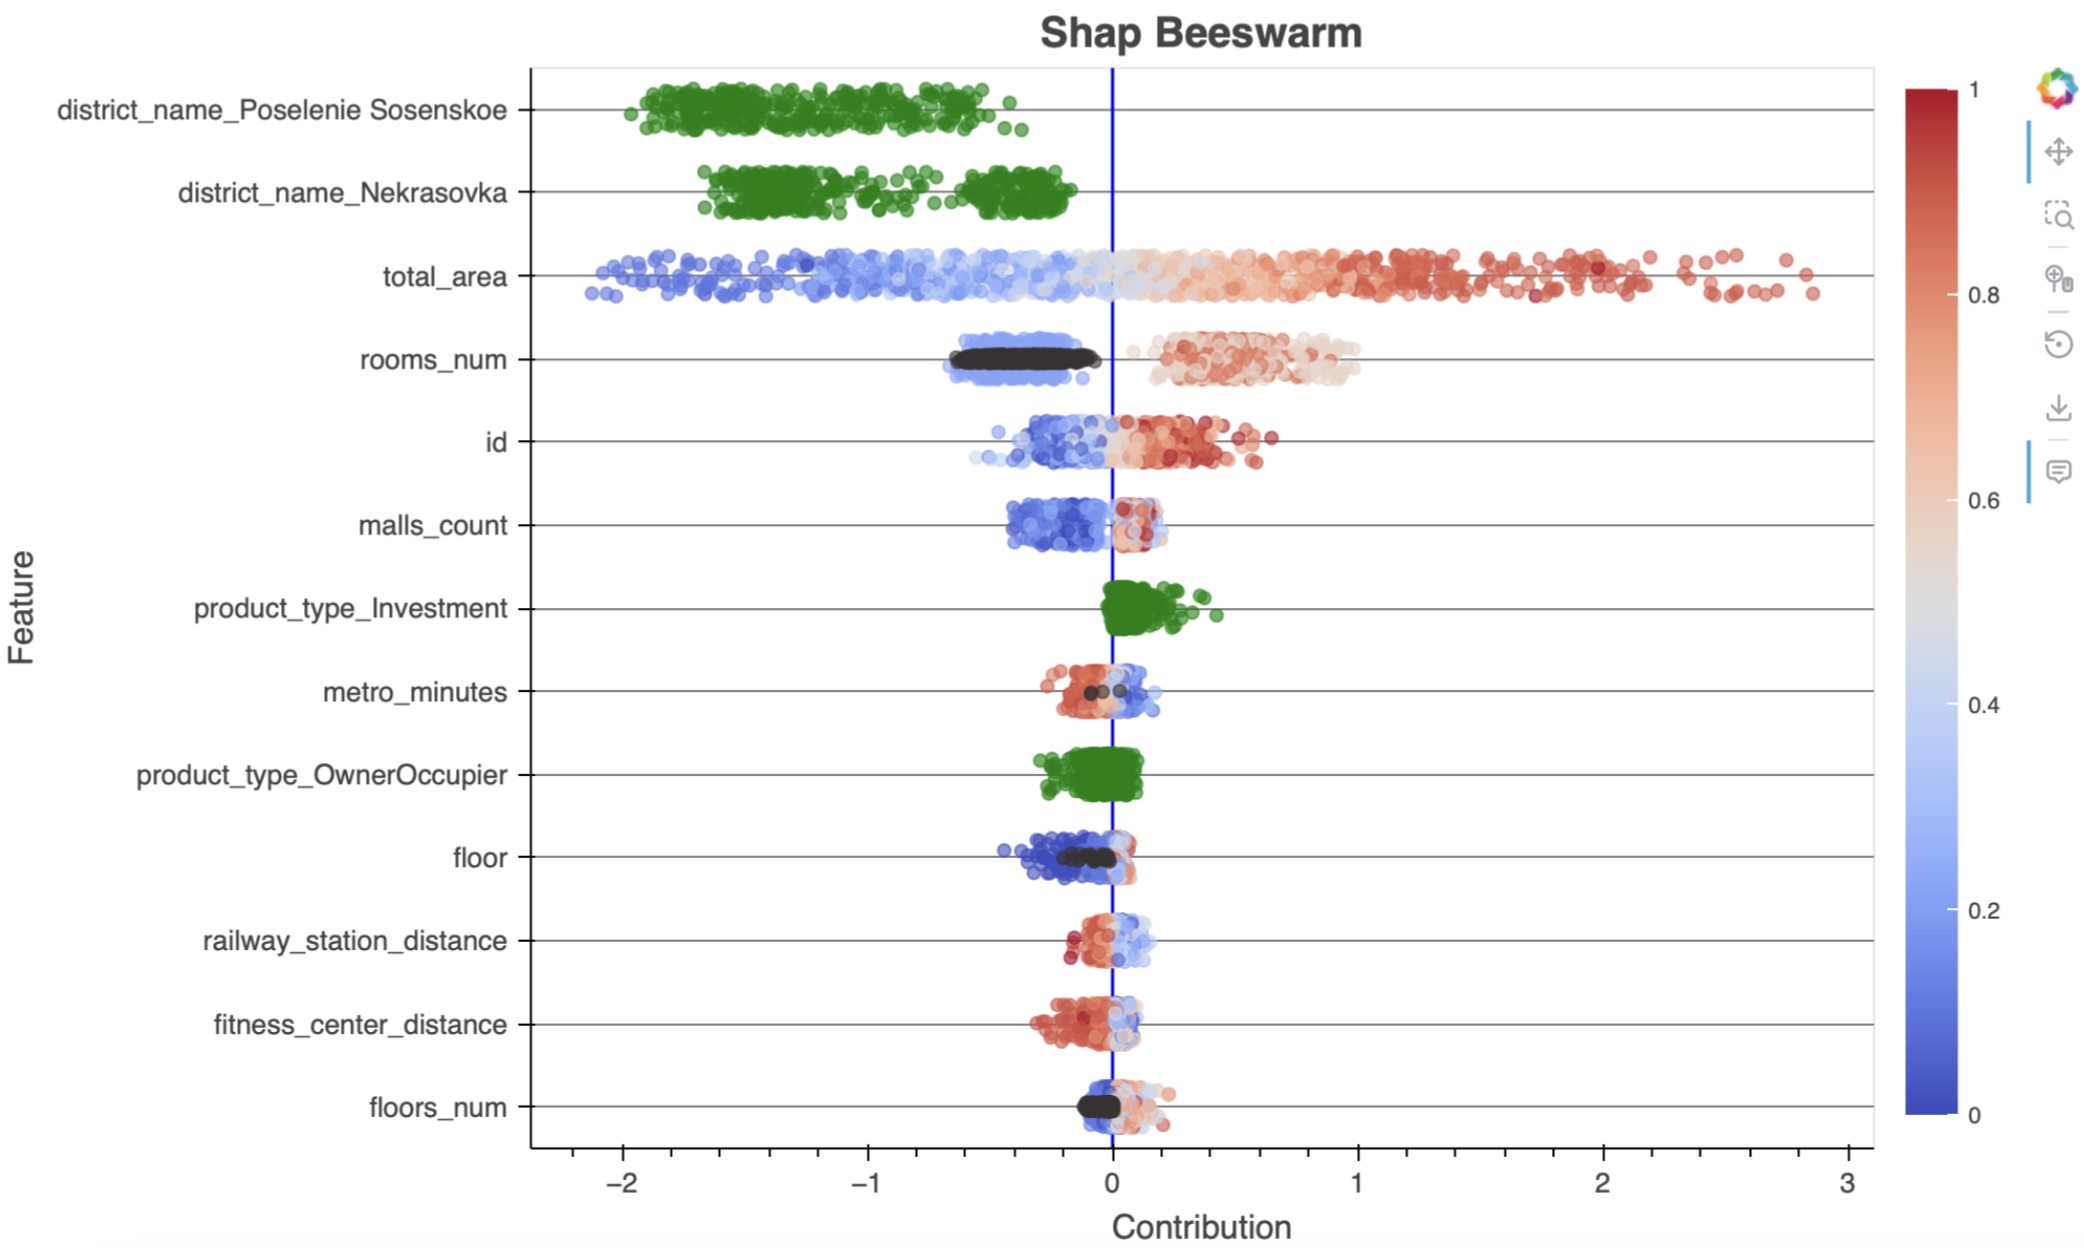

In [600]:
# картинка на случай если не хотите запускать

from IPython.display import Image
Image('task1.png')

## 2. Утилита для интерактивной кластеризации и интерпретации кластеров (6 баллов)

В этом блоке вам нужно будет самостоятельно написать bokeh-приложение для интерактивной кластеризации 2D-эмбеддингов
    с последующей интерпретацией различий между кластерами (тоже интерактивной!), по типу того, что я вам показывал на втором семинаре
    по интерпретации (в конце).

Вы принимаете на вход 2D-эмбеддинги ваших объектов, после чего рисуете их на плоскости ✅. Далее, у пользователя есть возможность с помощью Lasso
    выделять и назначать точкам кластеры (название + цвет). После этого, ниже, пользователь может запустить "сравнение" этих кластеров:
    по нажатию на кнопку под капотом запускается модель на подмножестве исходных данных: X.query('cluster_1 or cluster_2') с
    таргетом=метка_кластера (то есть мы учим модель отличать один кластер от другого). После обучения модели, мы выводим тот самый
    shap.plots.beeswarm с важностями признаков (тот, что вы делали в первом блоке.
    Если не делали, выводите родной шаповский или какую-нибудь пародию). Таким образом, мы можем интерактивно сравнивать кластеры между собой
    и понимать, чем они отличаются. Обратите внимание, что кластеры у вас образуются в пространстве эмбеддингов, а различия между ними мы ищем
    в пространстве оригинальных признаков! Для дополнительного понимания задания см. второй семинар по интерпретации.

Итак!

Ваше приложение должно принимать на вход:
- 2D-эмбеддинги каких-то оригинальных данных с признаками ✅
- Собственно, эти оригинальные данные ✅
- Список колонок, которые мы считаем "признаками", на которых =наша "модель" будет учиться различать кластеры. ✅
    Рассчитываем, что все типы колонок уже "правильные" для обучения модели
- sample_size -- если пользователь подал на вход больше чем sample_size точек, нужно отрисовывать только sample_size ✅
    (и модель обучать тоже на этом подмножестве). sample_size=None -- отрисовать все точки, однако не ставьте None по умолчанию, поставьте
    максимальное число, при котором утилита не лагает
- Что еще посчитаете нужным ✅

#### Реализация:
**Точки**

Отрисовываем sample_size точек из эмбеддингов на плоскости (изначально покрашенных в один цвет) ✅

**Выделение кластеров и раскраска**

Далее, пользователь может с помощью Lasso выделять любые точки и назначать им (цвет + название) = кластер (по кнопке). Сделайте так,
    чтобы пользователю предлагались какие-то названия (напр. 'cluster_1', 'cluster_2') и цвета (палитра для категорий).
    Эти кластеры должны сохраняться и быть выписаны где-нибудь рядом ✅. Также, при назначении кластера (по кнопке), он должен
    автоматически краситься в выбранный цвет на графике. ✅

**Сравнение кластеров**
Нужно добавить совокупность виджетов, которая позволила бы пользователю "сравнить два кластера", включая "N/A" кластер с неназначенными никакому кластеру точками (можно выпадающий список кластер_левый, кластер_правый). Выбираем два кластера, жмем "сравнить". Под капотом запускается обучение Lightgbm / Catboost с таргетом = номер кластера (левый класс 0, правый класс 1), с параметрами: objective=бинарная_классификация, 'boosting_type'=random_forest (адекватнее важности признаков) + все что нужно еще для того чтобы включился random forest (написано в доке какие еще параметры надо задать), обучаем деревьев 30-50 (обычно для различия кластеров этого хватает). Далее рисуем ниже (правее/левее/выше) shap.plots.beeswarm от этой модели. Его аргументы (напр. top_k, cat_feature_threshold) нужно задать в каком-нибудь блоке рядышком и он будет перестраиваться по кнопке). Если я снова нажму "сравнить" для других кластеров, эта картинка перерисовывается.
Если хотите, важные аргументы модели можете тоже вынести в виджеты. Обратите внимание, что если ваш гиперпараметр может принимать значения в диапазоне, условно, от 1e-5 до 1., то использовать для такого гиперпараметра виджет-ползунок -- плохая идея (используйте поле ввода). ✅


**!** Убедитесь, что у вас нигде нет никаких циклов по всем объектам и прочих ужасов!

In [5]:
# запустите вашу утилиту на этих эмбеддингах с данными и признаками из первого блока
embeddings = np.load('sber_data_emb.npy')
embeddings.shape

(6264, 2)

### решение

In [6]:
class ClustersAnalysis:
    """
    Interactive clustering analysis and comparision.

    Parameters
    ----------
    embed : np.ndarray
        2D embedding of shape (n_samples, 2).
    data : pandas.DataFrame
        Dataset aligned with the embedding.
    features : list 
        Feature columns used for model training and SHAP.
    sample_size : int
        Number of points to sample for visualization.

    Notes
    -----
    - to create a cluster one needs to select dots via lasso tool, select color and cluster name and press 'Save cluster'
    - to delete a cluster one needs to type its name into the 'Cluster name' box and press 'Remove cluster'
    - to delete all progress one can press 'Delete all'
    - when pressing 'compare clusters' the shap plot will be drawn automatically. 
        to update the shap plot using the same data press 'recompute shap plot'
    """
    def __init__(self, embed, data, features, sample_size = 10000, default_color = '#8F8F8F', default_name = 'N/A'):

        self.embed = embed
        self.data = data
        self.features = features
        self.default_color = default_color
        self.default_name = default_name

        self.clusters = {default_name: np.arange(self.embed.shape[0])}
        self.curr_cand = None
        self.x = 1
        self.palette = list(Category20[20])

        if sample_size:
            sample_size = min(sample_size, embed.shape[0])
            idx = np.random.choice(embed.shape[0], size = sample_size, replace = False)
            self.embed = self.embed[idx, :]
            self.data = self.data.iloc[idx, :].reset_index(drop=True)
        
        self.fig = self._create_figure()

  
    def _create_figure(self):
        fig = figure(
            #y_range=list(self.embed[:,1].min()),
            width=800, height=800,
            tools=["pan", 'lasso_select', "wheel_zoom","zoom_in","zoom_out","box_zoom","undo","reset","box_select","fullscreen", "tap"],
            title = 'Embedding analysis', 
        )

        fig.title.align = "center"
        fig.title.text_font_size = "15pt"
        fig.title.text_font_style = "bold"
        fig.xaxis.major_label_text_font_size = "10pt"
        fig.yaxis.major_label_text_font_size = "10pt"

        self.source = ColumnDataSource({'embed0': self.embed[:, 0],
                                        'embed1': self.embed[:, 1],
                                        'cluster': np.array([self.default_name]*self.embed.shape[0], dtype=object),
                                        'color': np.array([self.default_color]*self.embed.shape[0], dtype=object)})

        self.source.selected.on_change("indices", self.update_selection)
        
        fig.circle(
            x="embed0",
            y='embed1',
            source=self.source,
            size=6,
            color='color',
            alpha=0.6
        )
        
        hover = HoverTool(tooltips=[("cluster_name", "@cluster")])
        fig.add_tools(hover)

        # WIDGETS

        # buttons (handle clusters)
        copybutton_colors = InlineStyleSheet(css="""
            .bk-btn {
                font-size: 18px !important;  
                font-weight: bold;
                text-align: center !important;}
                """)
        self.add_cluster_button = Button(label = 'Add cluster', width = 250, height = 50, button_type="success", stylesheets=[copybutton_colors])
        self.rem_cluster_button = Button(label = 'Remove cluster', width = 250, height = 50, button_type="warning", stylesheets=[copybutton_colors])
        self.rem_all_button = Button(label = 'Remove all', width = 250, height = 50, button_type="danger", stylesheets=[copybutton_colors])

        self.add_cluster_button.on_click(self.push_add_cluster)
        self.rem_cluster_button.on_click(self.push_rem_cluster)
        self.rem_all_button.on_click(self.push_rem_all)

        # new cluster name
        selectionbox_style = InlineStyleSheet(css="""
            .bk-input-group label {
                text-align: center !important;
                width: 100% !important;
                display: block !important;
                font-size: 16px !important;  
                font-weight: bold;
            }
            .bk-input {
                color: black !important;
                background-color: white !important;
                font-size: 20px !important;  
                text-align: center !important;
            }
            """)
        self.cand_cluster_name = TextAreaInput(title="Cluster name", value=f"cluster_1", width = 250, height=75, stylesheets=[selectionbox_style])        
        self.color_select = ColorPicker(title="Choose color!", color=self.palette[0], width=250, height=75, stylesheets=[selectionbox_style])
        
        self.cluster_table_source = ColumnDataSource(data=dict(cluster_name=[self.default_name], num_points=[self.embed.shape[0]], color=[self.default_color]))

        color_template = """
            <div style="
                width: 70px; 
                height: 20px; 
                background-color:<%= color %>; 
                border: 1px solid black;
                border-radius: 4px;
            "></div>
            """
        color_formatter = HTMLTemplateFormatter(template=color_template)
        black_text_formatter = HTMLTemplateFormatter(template="""<div style="color: black; text-align: center"><%= value %></div>""")
        columns = [
            TableColumn(field="cluster_name", title="cluster name", formatter=black_text_formatter),
            TableColumn(field="num_points", title="points number",formatter=black_text_formatter),
            TableColumn(field="color", title="color", formatter=color_formatter)
        ]

        self.cluster_table = DataTable(source=self.cluster_table_source,columns=columns, width=250, height=300, index_position=None)

        self.select_cluster1 = Select(title = 'Select cluster #1', width = 250, height = 50,value=list(self.clusters.keys())[0], options=list(self.clusters.keys()), stylesheets=[selectionbox_style])
        self.select_cluster2 = Select(title = 'Select cluster #2', width = 250, height = 50,value=list(self.clusters.keys())[0], options=list(self.clusters.keys()), stylesheets=[selectionbox_style])
        self.compare_button = Button(label = 'Compare clusters', width = 250, height = 50, button_type="primary", stylesheets=[copybutton_colors])
        self.compare_button.on_click(self.compare_clusters)

        self.bees_maxfeatures = TextAreaInput(title="Max features to show", value=f"10", width = 200, height=75, stylesheets=[selectionbox_style])
        self.cat_thr = TextAreaInput(title="Category thershold", value=f"0.05", width = 200, height=75, stylesheets=[selectionbox_style])
        self.num_dots = TextAreaInput(title="Number of dots per feature", value=f"1000", width = 200, height=75, stylesheets=[selectionbox_style])
        self.cat_color = ColorPicker(title="Category color", color='green', width=200, height=75, stylesheets=[selectionbox_style])

        self.draw_shapplot = Button(label = 'RECOMPUTE SHAP PLOT', width = 800, height = 50, button_type="danger", stylesheets=[copybutton_colors])
        self.draw_shapplot.on_click(self.draw_shap)
        self.shap_container = column() 
        return fig



    
    def update_selection(self, attr, old, new):
        self.curr_cand_idx = new


    def compare_clusters(self):
        cluster1, cluster2 = self.select_cluster1.value, self.select_cluster2.value 
        if cluster1 == cluster2:
            print('Can not compare cluster with itself. Choose two different clusters')
            return

        idx1, idx2 = self.clusters[cluster1], self.clusters[cluster2]
        common = np.hstack([idx1, idx2])

        self.X, y = self.data[self.features].iloc[common, :], np.array([0]*len(idx1) + [1]*len(idx2))
        model = LGBMClassifier(
            objective='binary',
            boosting_type='rf',
            n_estimators=30,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )
        model.fit(self.X, y)
        self.shap_values = model.predict(self.X, pred_contrib=True)
        self.draw_shap()

    def draw_shap(self):
        mf = int(self.bees_maxfeatures.value)
        cat_thr = float(self.cat_thr.value)
        num_dots = int(self.num_dots.value)
        cat_color = self.cat_color.color
        
        new_plot = ShapBeeswarm(self.shap_values, from_lbg = True, df = self.X, max_features = mf, cat_thr = cat_thr, num_dots = num_dots, cat_color = cat_color).layout()
        self.shap_container.children = [new_plot]
        
        
    def push_add_cluster(self):
        new_data = dict(self.source.data)
        new_data['cluster'][self.curr_cand_idx] = np.array([self.cand_cluster_name.value] * len(self.curr_cand_idx))
        new_data['color'][self.curr_cand_idx] = np.array([self.color_select.color] * len(self.curr_cand_idx))
        self.source.data = new_data
        self.clusters[self.cand_cluster_name.value] = np.array(self.curr_cand_idx, dtype=int)
        self.clusters[self.default_name] = np.array(list(set(self.clusters[self.default_name].tolist()) - set(self.curr_cand_idx)))
        self.x += 1
        self.cand_cluster_name.value = f"cluster_{len(self.clusters)}" if not f"cluster_{len(self.clusters)}" in self.clusters else f"cluster_{self.x}"
        avail = list(set(self.palette) - set(self.source.data['color'].tolist()))
        self.update_cluster_table()
        self.select_cluster1.options = list(self.clusters.keys())
        self.select_cluster2.options = list(self.clusters.keys())
        
    def push_rem_cluster(self):
        cluster_delete_name = self.cand_cluster_name.value
        cluster_delete_idx = self.clusters[cluster_delete_name]
        new_data = dict(self.source.data)
        new_data['cluster'][cluster_delete_idx] = np.array([self.default_name] * len(cluster_delete_idx))
        new_data['color'][cluster_delete_idx] = np.array([self.default_color] * len(cluster_delete_idx))
        self.source.data = new_data
        del self.clusters[cluster_delete_name]
        self.clusters[self.default_name] = np.array(list(set(self.clusters[self.default_name].tolist()) | set(cluster_delete_idx)))
        self.x += 1
        self.cand_cluster_name.value = f"cluster_{len(self.clusters)}" if not f"cluster_{len(self.clusters)}" in self.clusters else f"cluster_{self.x}"
        avail = list(set(self.palette) - set(self.source.data['color'].tolist()))
        self.update_cluster_table()
        self.select_cluster1.options = list(self.clusters.keys())
        self.select_cluster2.options = list(self.clusters.keys())

    def push_rem_all(self):
        new_data = {'embed0': self.embed[:, 0],
                    'embed1': self.embed[:, 1],
                    'cluster': np.array([self.default_name]*self.embed.shape[0], dtype=object),
                    'color': np.array([self.default_color]*self.embed.shape[0], dtype=object)}

        self.source.data = new_data
        self.clusters = {self.default_name: np.arange(self.embed.shape[0])}
        self.curr_cand = None
        self.cand_cluster_name.value = "cluster_1"
        self.x = 1
        self.update_cluster_table()
        self.select_cluster1.options = list(self.clusters.keys())
        self.select_cluster2.options = list(self.clusters.keys())

    def update_cluster_table(self):
        cluster_names = []
        num_points = []
        colors = []

        for name, idxs in self.clusters.items():
            cluster_names.append(str(name)) 
            num_points.append(int(len(idxs))) 
            colors.append(str(self.source.data['color'][idxs[0]]))

        self.cluster_table_source.data = dict(
            cluster_name=cluster_names,
            num_points=num_points,
            color=colors
        )
        

    def layout(self):
        return column(row(self.fig, 
                        column(self.cand_cluster_name, self.color_select, self.add_cluster_button, self.rem_cluster_button, self.rem_all_button, self.cluster_table)), 
                      row(self.select_cluster1, self.select_cluster2, self.compare_button),
                      row(self.bees_maxfeatures, self.cat_thr, self.num_dots, self.cat_color),
                    self.draw_shapplot,
                    self.shap_container) 
    

In [7]:
def app(doc):
    viz = ClustersAnalysis(embeddings, df, features)
    doc.add_root(viz.layout())

show(app)

### скрины решения

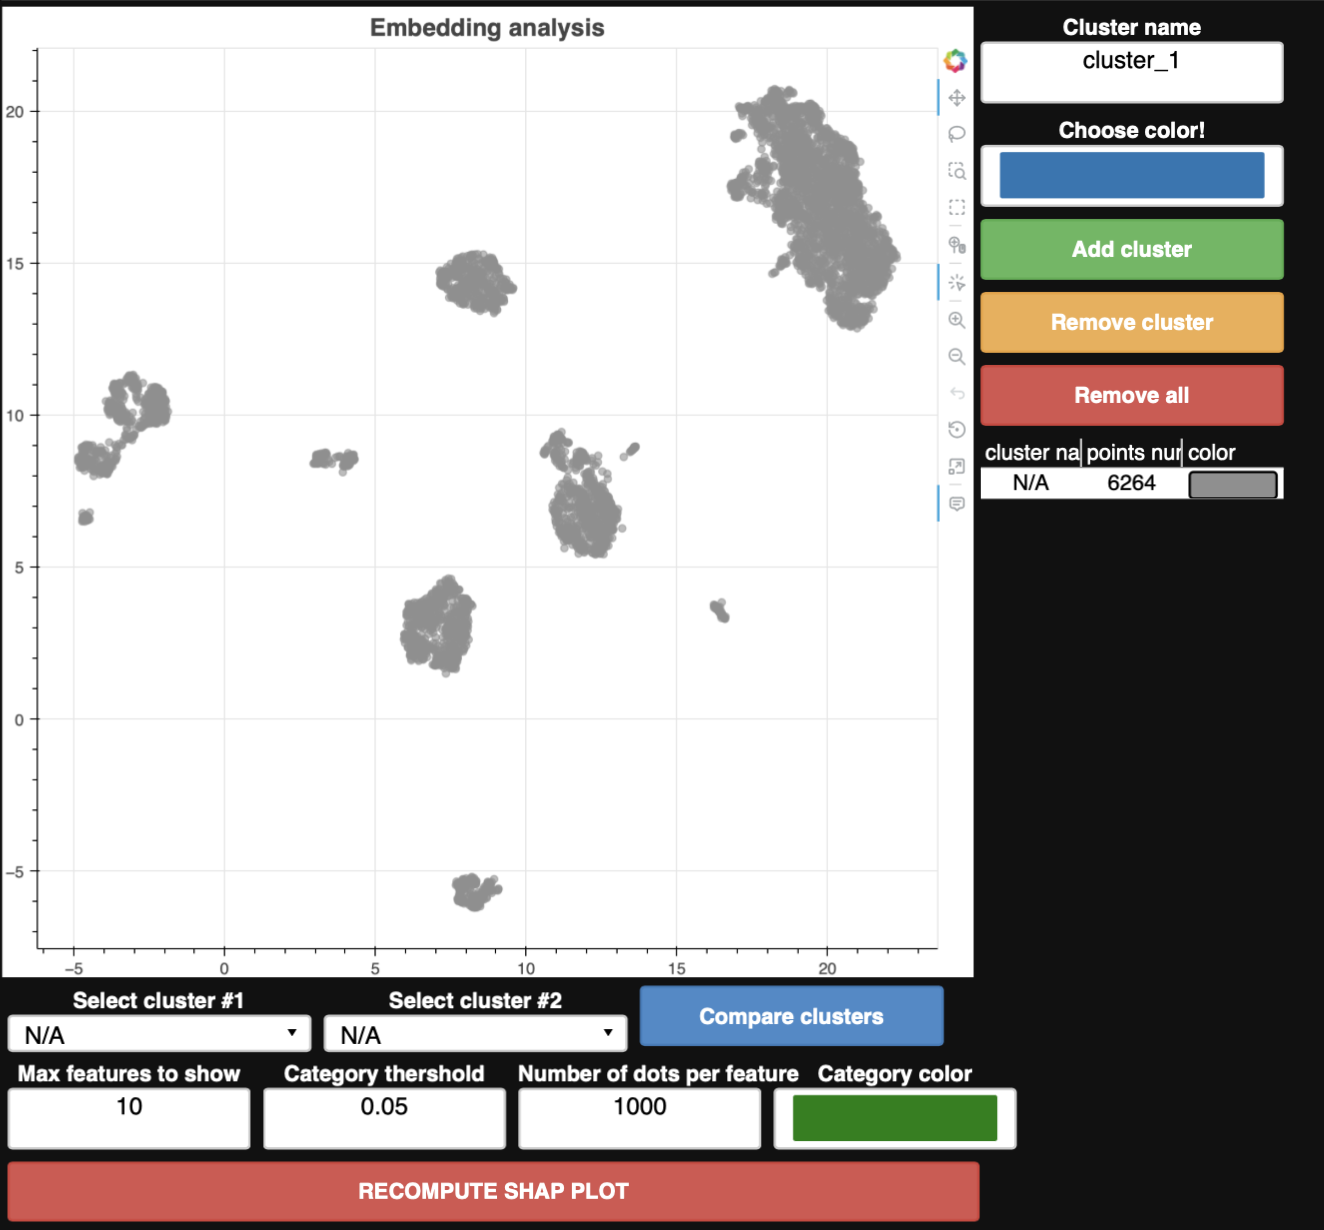

In [609]:
# и парочка моих примеров
Image('task2_1.png', width=600)

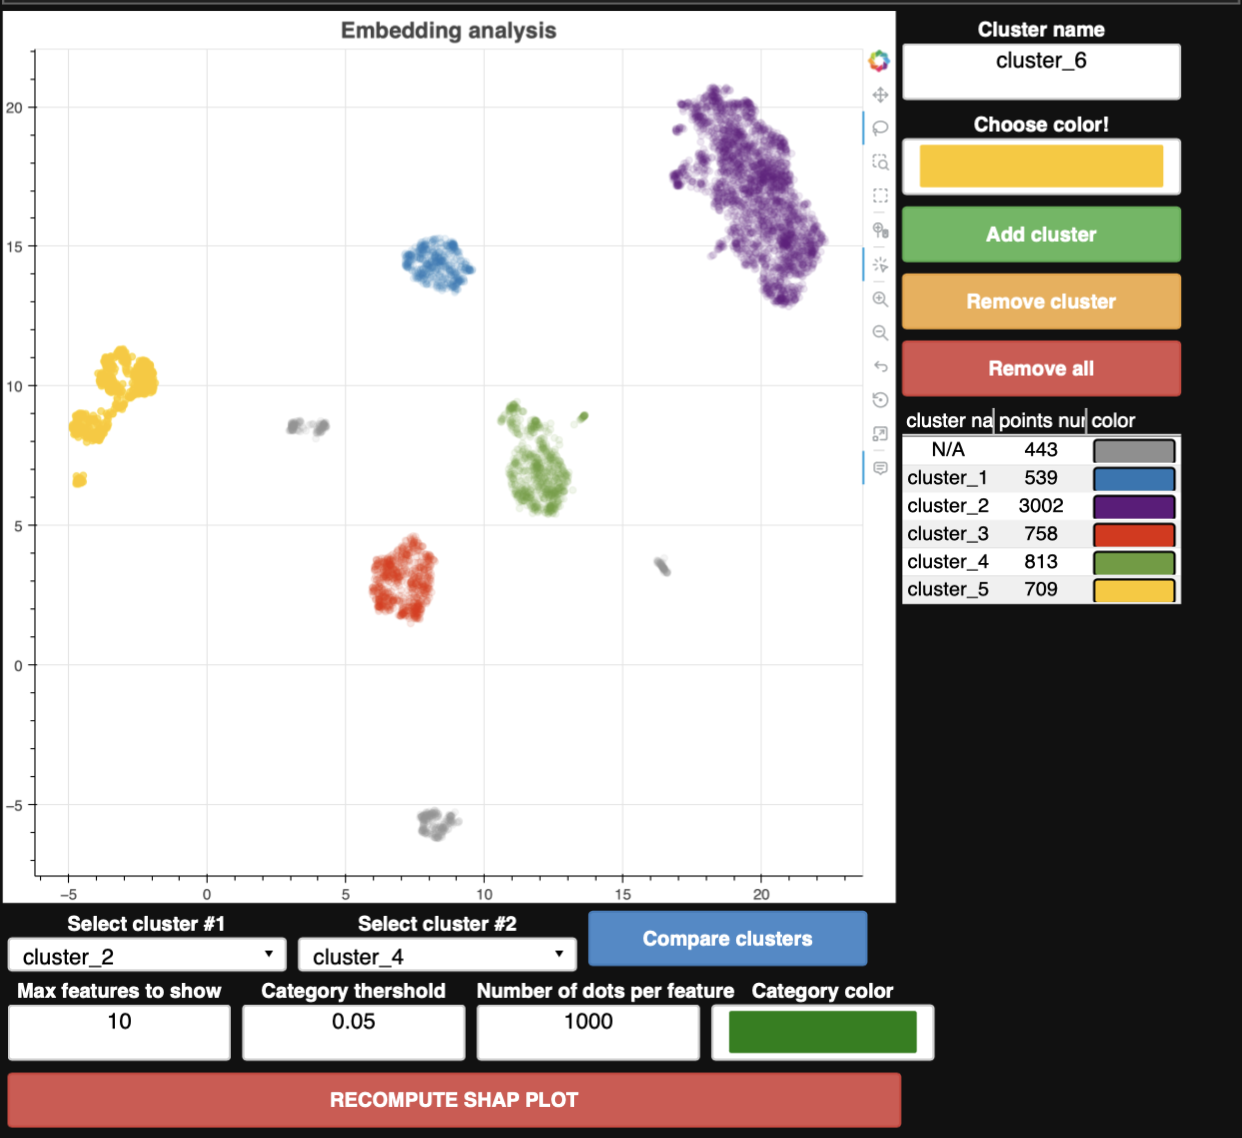

In [610]:
Image('task2_2.png', width=600)

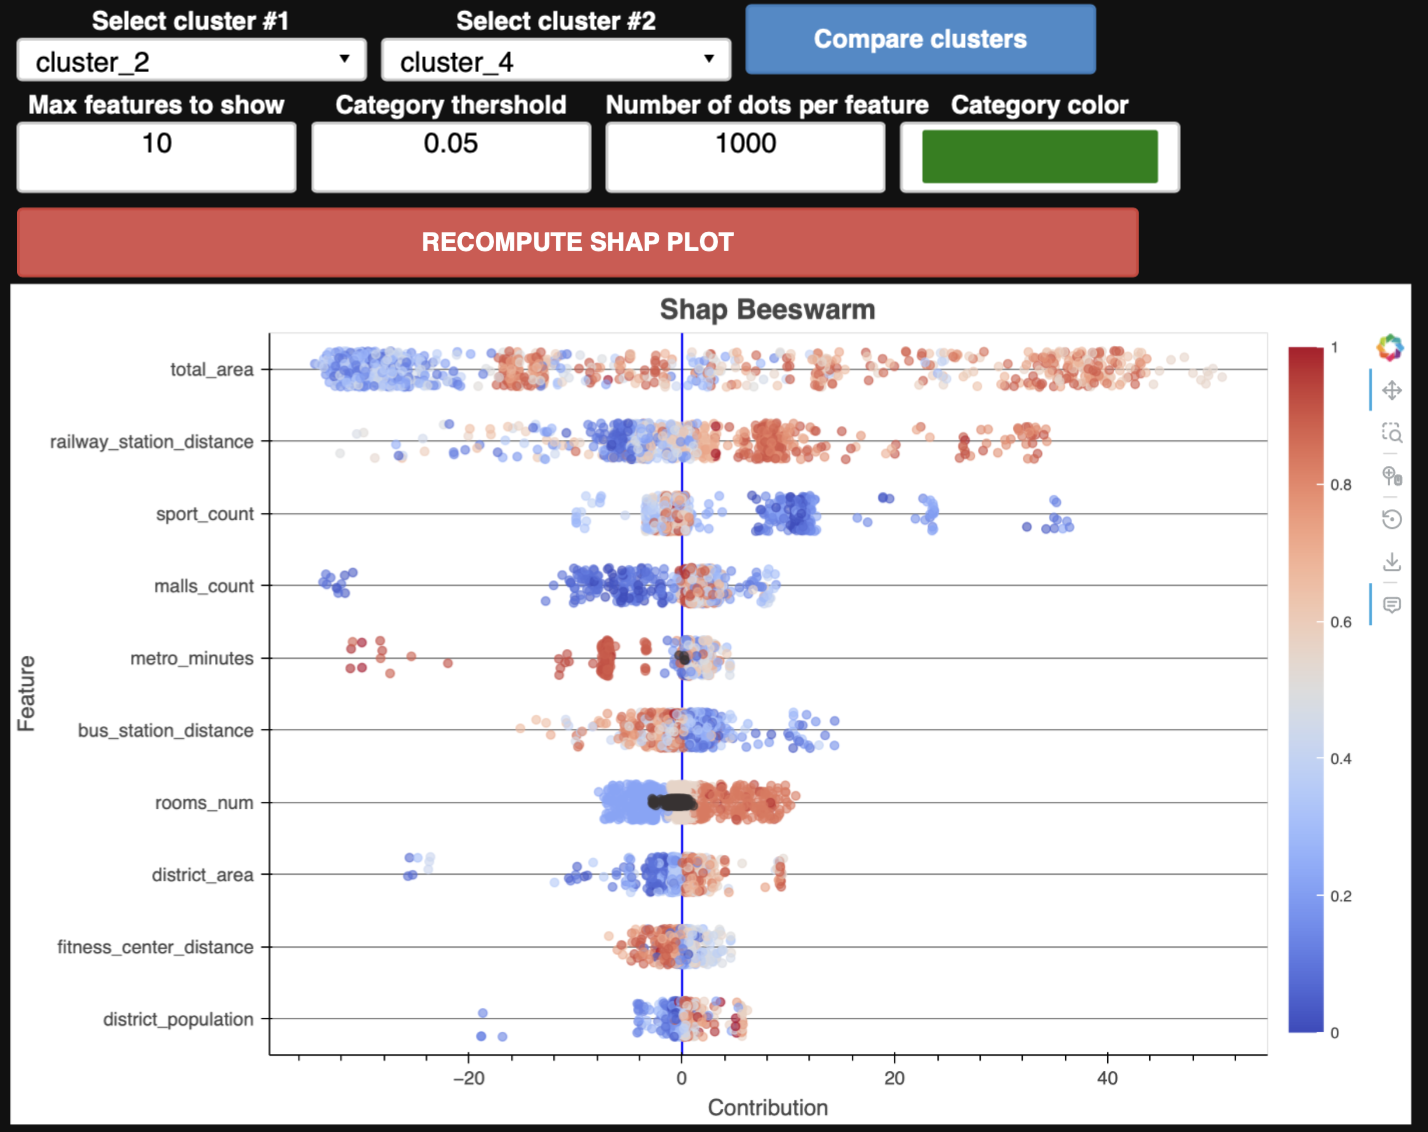

In [611]:
Image('task2_3.png', width=600)

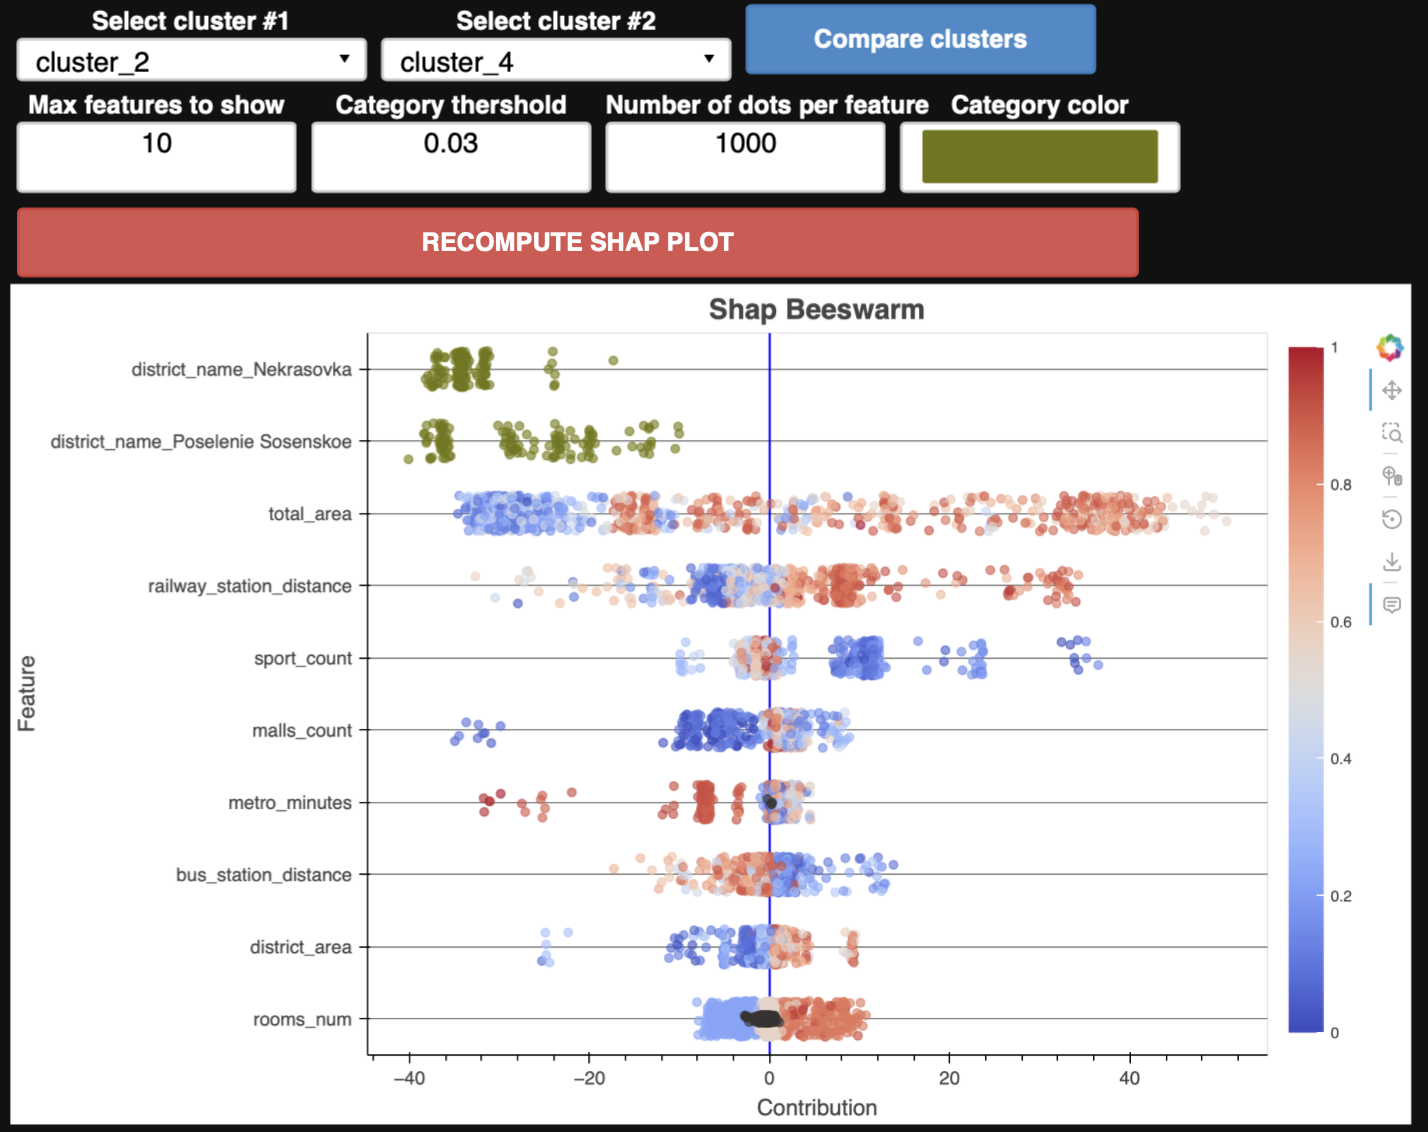

In [612]:
Image('task2_4.png', width=600)

### Пример ниже. Не удаляйте пример!

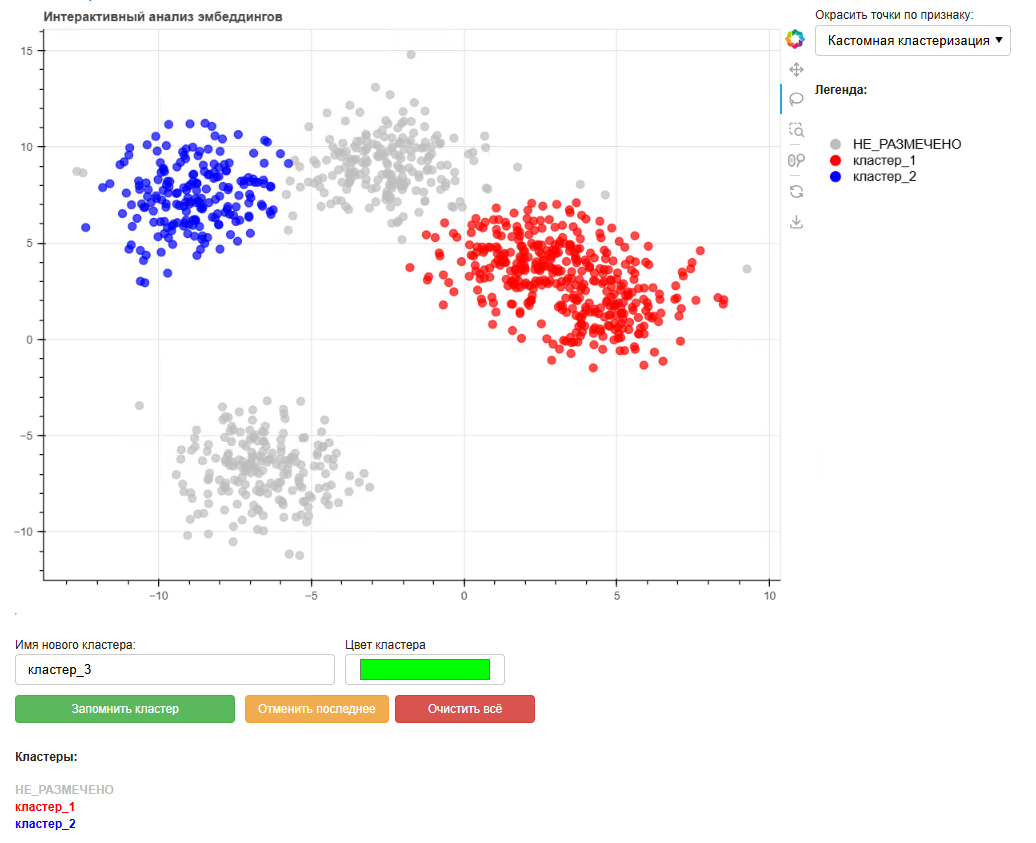

In [ ]:
from IPython.display import Image

Image('1.png', width=600)

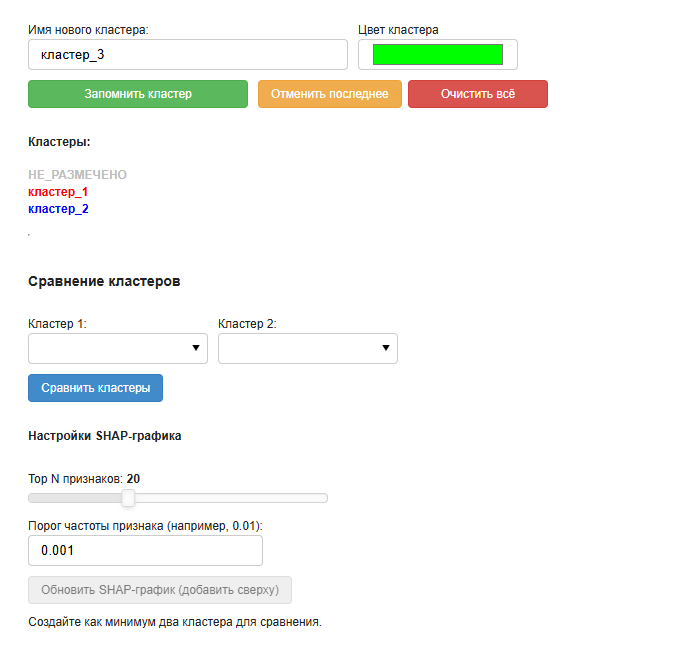

In [ ]:
Image('2.png', width=500)

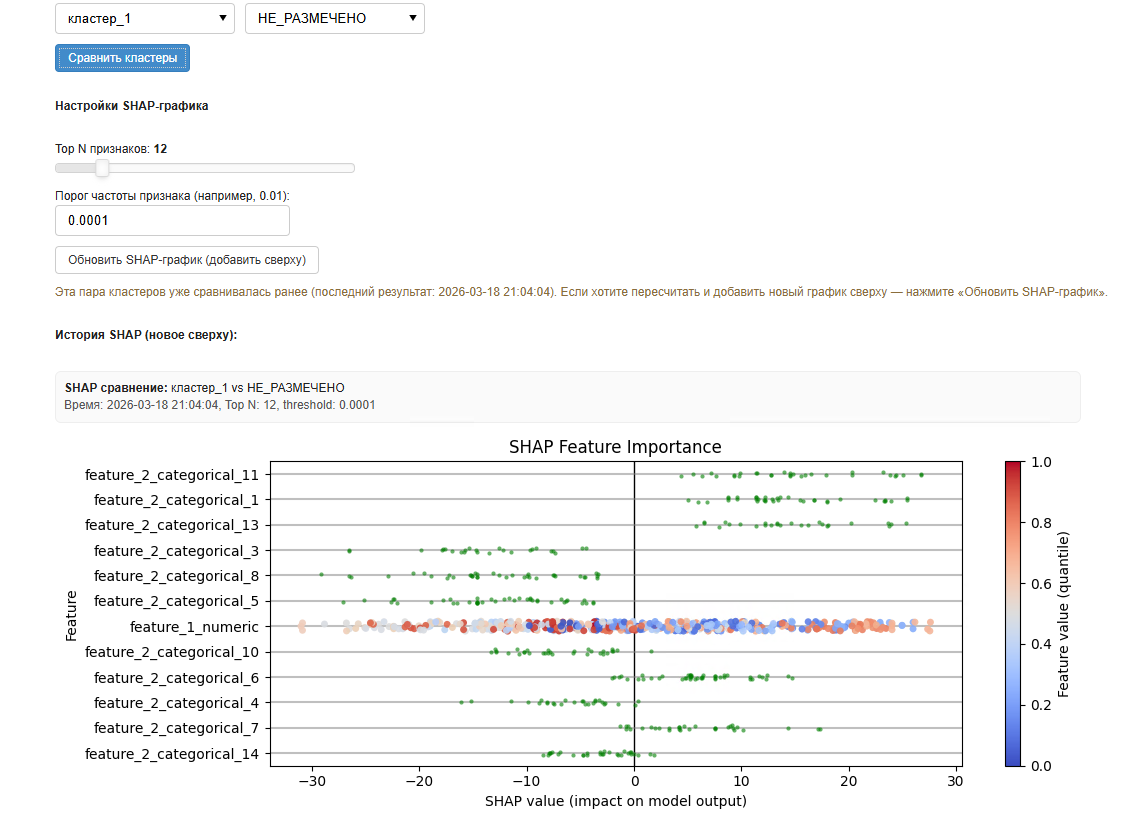

In [ ]:
Image('3.png', width=800)